# Final Assignment – Introduction to Machine Learning

# Part 1: Linear Classifiers and Model Evaluation


**Section 1.1  Model Evaluation Warm-up**

|                    | Actual Spam | Actual Not Spam |
| ------------------ | ----------: | --------------: |
| Predicted Spam     |     60 (TP) |         15 (FP) |
| Predicted Not Spam |     10 (FN) |        115 (TN) |


**1.1 Q1:**
By hand, showing your working, compute Accuracy, Precision, Recall, and F1-score for the Spam class?

**Answer:**

**Accuracy:**

Accuracy = $\frac{TP + TN}{TP + TN + FP + FN}$

= $\frac{60 + 115}{60 + 115 + 15 + 10}$
= $\frac{175}{200}$

Accuracy= $0.875$ or $87.5\%$

**Precision:**

Precision= $\frac{TP}{TP + FP}$
= $\frac{60}{60 + 15}$
= $\frac{60}{75}$
Precision = $0.80$ or $80\%$

**Recall:**

Recall = $\frac{TP}{TP + FN}$

= $\frac{60}{60 + 10}$

= $\frac{60}{70}$

Recall= $0.8571$ or $85.71\%$

**F1 Score:**

F1 Score= $2 \times \frac{Precision \times Recall}{Precision + Recall}$

= $2 \times \frac{0.80 \times 0.8571}{0.80 + 0.8571}$

= $\frac{1.37136}{1.6571}$

F1 Score = $0.8276$ or $82.76\%$


**1.1 Q2:**
In 3-4 sentences, explain whether precision or recall should be prioritized when designing a
spam filter, and why?

**Answer:**
For a spam filter, precision and recall are both important, but precision is given slightly higher priority. A high precision means that emails classified as spam are actually spam, reducing the chance of important emails being sent to the spam folder. Although high recall helps catch more spam emails, excessively prioritizing recall may incorrectly classify many genuine emails as spam, which is more harmful for users.






**Section 1.2 Perceptron Learning**


|          Class          | Label | Mean(x1,x2) | Samples |
|--------------------|------------:|----------------:|------:|
|          A         |     -1      |      (1,1)      |  150  |
|          B         |     +1      |      (5,5)      |  150  |

In [1]:
# 1.2 Q1
# Question 1: Generate the dataset above (2-D Gaussian per class). Combine, shuffle with a fixed random
#             seed, and split 80:20 into train/test?



# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Random seed for reproducibility
np.random.seed(42)

# Dataset parameters
samples_per_class = 150

mean_A = [1, 1]
mean_B = [5, 5]

cov = np.eye(2)

# Generate Class A (-1)
X_A = np.random.multivariate_normal(mean_A, cov, samples_per_class)
y_A = -np.ones(samples_per_class)

# Generate Class B (+1)
X_B = np.random.multivariate_normal(mean_B, cov, samples_per_class)
y_B = np.ones(samples_per_class)

# Combine
X = np.vstack((X_A, X_B))
y = np.hstack((y_A, y_B))

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))


Training Samples : 240
Testing Samples : 60


In [2]:
# 1.2 Q2
# Question 2:Implement the Perceptron Learning Algorithm from scratch: zero-initialized weights, mistake
#            driven updates (w ← w +yixi whenever yi⟨w,xi⟩ ≤ 0), and early stopping once a full pass
#            makes zero mistakes. Report the final weight vector, bias, and the number of epochs to
#            convergence?
# Answer:

class Perceptron:

    def __init__(self):

        self.weights = None
        self.bias = 0

    def fit(self, X, y):

        samples, features = X.shape

        self.weights = np.zeros(features)
        self.bias = 0

        epoch = 0

        while True:

            mistakes = 0

            for i in range(samples):

                activation = np.dot(self.weights, X[i]) + self.bias

                if y[i] * activation <= 0:

                    self.weights = self.weights + y[i] * X[i]
                    self.bias = self.bias + y[i]

                    mistakes += 1

            epoch += 1

            if mistakes == 0:
                break

        return epoch

    def predict(self, X):

        activation = np.dot(X, self.weights) + self.bias

        prediction = np.where(activation >= 0, 1, -1)

        return prediction


# Train Perceptron

perceptron = Perceptron()

epochs = perceptron.fit(X_train,y_train)

print("Final Weight Vector")
print(perceptron.weights)

print()

print("Final Bias")
print(perceptron.bias)

print()

print("Epochs to Convergence")
print(epochs)

Final Weight Vector
[4.25096966 4.50965041]

Final Bias
-23.0

Epochs to Convergence
6


In [3]:
# 1.2 Q3
# Question 3:Evaluate the trained model on the test set using the Accuracy, Precision, Recall, and F1
#            formulas from Section 1.1.

# Answer:

# Prediction

predictions = perceptron.predict(X_test)

TP = np.sum((predictions == 1) & (y_test == 1))
TN = np.sum((predictions == -1) & (y_test == -1))
FP = np.sum((predictions == 1) & (y_test == -1))
FN = np.sum((predictions == -1) & (y_test == 1))

print("Confusion Matrix")
print(f"True Positive  (TP): {TP}")
print(f"True Negative  (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")

accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1_score = (2 * precision * recall) / (precision + recall)

print("Accuracy :" ,accuracy.round(4))
print("Precision :" ,precision.round(4))
print("Recall :" ,recall.round(4))
print("F1 Score :" ,f1_score.round(4))


Confusion Matrix
True Positive  (TP): 31
True Negative  (TN): 28
False Positive (FP): 1
False Negative (FN): 0
Accuracy : 0.9833
Precision : 0.9688
Recall : 1.0
F1 Score : 0.9841


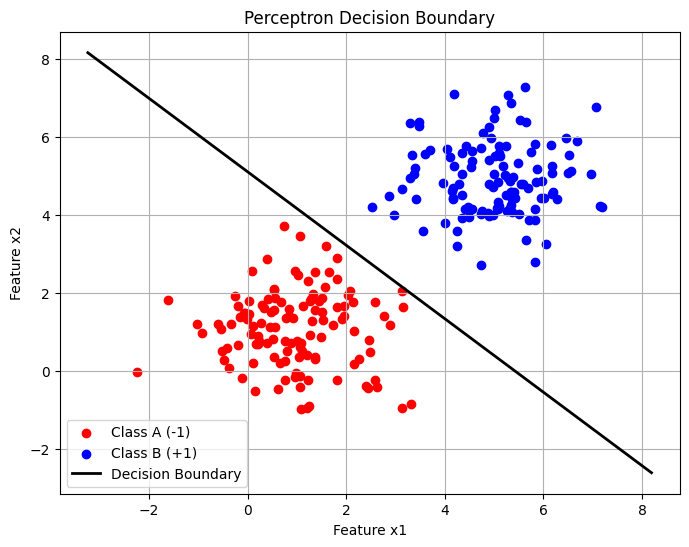

In [4]:
# 1.2 Q4
# Question 4:Plot the learned decision boundary together with the training data points?
# Answer:

# Plot Decision Boundary

plt.figure(figsize=(8, 6))

# Plot Class A (-1)
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], color="red", label="Class A (-1)")

# Plot Class B (+1)
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color="blue", label="Class B (+1)")

# Decision Boundary
x_values = np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 100)

# y = -(w1*x + b)/w2
y_values = -(perceptron.weights[0] * x_values + perceptron.bias) / perceptron.weights[1]

plt.plot(x_values, y_values, color="black", linewidth=2, label="Decision Boundary")

plt.xlabel("Feature x1")
plt.ylabel("Feature x2")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()

In [5]:
# 1.2 Q5

# Question 5: Randomly flip the labels of 10% of the training samples (simulating noisy/mislabeled data)
#             and retrain from scratch. Report what happens to convergence and to test performance, and
#             explain why, referencing the linear-separability assumption behind the Perceptron Conver
#             gence Theorem?

# Add 10% Label Noise

np.random.seed(42)

# Copy original labels
y_train_noisy = y_train.copy()

# Number of labels to flip
num_flip = int(0.10 * len(y_train))

# Random indices
flip_indices = np.random.choice(len(y_train), size=num_flip, replace=False)

# Flip labels
y_train_noisy[flip_indices] *= -1

print("Number of labels flipped :", num_flip)




Number of labels flipped : 24


In [6]:
# 1.2 Q5

# Train Perceptron on Noisy Data


# noisy_perceptron = Perceptron()

# noisy_epochs = noisy_perceptron.fit(X_train, y_train_noisy)

# print("=" * 40)
# print("Training Results (Noisy Data)")
# print("=" * 40)

# print(f"Final Weight Vector : {noisy_perceptron.weights}")
# print(f"Final Bias          : {noisy_perceptron.bias}")
# print(f"Epochs              : {noisy_epochs}")

**Observation:**
In the fit() the while True works perfectly fine, but after adding 10% label noise, the data is no longer linearly separable which leads the Perceptron to never converge, causing the notebook to run forever.

In [7]:
# 1.2 Q6
# Question 6:Apply z-score normalization to both features (using training statistics only) and retrain
#            the original, noise-free perceptron. Compare the number of epochs to convergence against
#            Question 2, and explain the difference.

# Answer:

# Z-Score Normalization

train_mean = np.mean(X_train, axis=0)
train_std = np.std(X_train, axis=0)

# Normalize training and testing data
X_train_norm = (X_train - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print("Training Mean :", train_mean)
print("Training Standard Deviation :", train_std)

# Train Perceptron on Normalized Data

normalized_perceptron = Perceptron()

normalized_epochs = normalized_perceptron.fit(X_train_norm, y_train)

# Comparing epochs
print("=" * 40)
print("Training Results (Normalized Data)")
print("=" * 40)

print("Final Weight Vector :",normalized_perceptron.weights)
print("Final Bias          :",normalized_perceptron.bias)
print("Epochs              :",normalized_epochs)

Training Mean : [2.9647455  2.97849852]
Training Standard Deviation : [2.24748845 2.14473898]
Training Results (Normalized Data)
Final Weight Vector : [1.22129621 1.41140596]
Final Bias          : 0.0
Epochs              : 2


### Explanation

Z-score normalization scales each feature to have a mean of 0 and a standard deviation of 1 using only the training data statistics. This places both features on the same scale, allowing the Perceptron to update its weights more consistently. As a result, the model may converge in fewer epochs. If the number of epochs remains similar, it suggests that the original features were already on comparable scales.

**Section 1.3 – Support Vector Machines**


|          Class          | Label | Mean(x1,x2) | Samples |
|--------------------|------------:|----------------:|------:|
|          0         |     -1      |      (2,2)      |  150  |
|          1         |     +1      |      (4,4)      |  150  |

In [8]:
# 1.3 Q1
# Question1:Generate the dataset above, convert labels to {−1,+1}, z-score normalize both features
#           (training statistics only), and split 80:20.
# Answer:

# Generating Dataset

np.random.seed(42)

samples = 150

mean_class0 = [2, 2]
mean_class1 = [4, 4]

covariance = 2 * np.eye(2)

# Class 0
X0 = np.random.multivariate_normal(
    mean=mean_class0,
    cov=covariance,
    size=samples
)

y0 = -np.ones(samples)

# Class 1
X1 = np.random.multivariate_normal(mean=mean_class1, cov=covariance, size=samples)

y1 = np.ones(samples)

# Combine Dataset
X = np.vstack((X0, X1))
y = np.concatenate((y0, y1))

print("Total Samples :", len(X))

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

# Z-Score Normalization

train_mean = np.mean(X_train, axis=0)
train_std = np.std(X_train, axis=0)

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("Training Mean :", train_mean)
print("Training Standard Deviation :", train_std)

Total Samples : 300
Training Samples : 240
Testing Samples : 60
Training Mean : [2.9653795  2.98482921]
Training Standard Deviation : [1.73417722 1.6074637 ]


**Question 2:**
 Implement Soft-Margin SVM by minimizing
$J(w,b) = \frac{1}{2}\|w\|^2 + C \sum_{i=1}^n \max(0, 1 - y_i(w^T x_i + b))$

In [9]:
# 1.3 Q2
# Answer2:
# Soft Margin SVM from Scratch

class SoftMarginSVM:

    def __init__(self, learning_rate=0.01, C=1.0, epochs=1000):

        self.learning_rate = learning_rate
        self.C = C
        self.epochs = epochs

        self.weights = None
        self.bias = 0

    def fit(self, X, y):

        samples, features = X.shape

        self.weights = np.zeros(features)
        self.bias = 0

        for epoch in range(self.epochs):

            dw = np.zeros(features)
            db = 0

            # Batch Subgradient
            for i in range(samples):

                margin = y[i] * (np.dot(X[i], self.weights) + self.bias)

                if margin >= 1:

                    # Only regularization contributes
                    dw += self.weights

                else:

                    # Regularization + hinge loss
                    dw += self.weights - self.C * y[i] * X[i]
                    db += -self.C * y[i]

            # Average gradient
            dw /= samples
            db /= samples

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):

        scores = np.dot(X, self.weights) + self.bias

        return np.where(scores >= 0, 1, -1)

    def accuracy(self, X, y):

        prediction = self.predict(X)

        return np.mean(prediction == y)

    def margin_width(self):

        return 2 / np.linalg.norm(self.weights)

    def support_vectors(self, X, y):

        margin = y * (np.dot(X, self.weights) + self.bias)

        return np.where(margin <= 1)[0]

**Question 3:**
Train two models: one with strong regularization (C = 0.5) and one with weak regularization
(C = 50). For each, report the final weights and bias, test accuracy, margin width M =
2/∥w∥, and number of support vectors.

In [10]:
# 1.3 Q3

# Answer3:

# Train SVM (C = 0.5)

svm_c05 = SoftMarginSVM(learning_rate=0.01, C=0.5, epochs=1000)

svm_c05.fit(X_train, y_train)


# Results (C = 0.5)

accuracy_c05 = svm_c05.accuracy(X_test, y_test)

margin_c05 = svm_c05.margin_width()

support_vectors_c05 = svm_c05.support_vectors(X_train, y_train)

print("=" * 50)
print("Soft Margin SVM (C = 0.5)")
print("=" * 50)

print("Final Weight Vector")
print(svm_c05.weights)

print()

print("Final Bias")
print(svm_c05.bias)

print()

print("Test Accuracy :",accuracy_c05.round(4))

print("Margin Width :", margin_c05.round(4))

print("Number of Support Vectors :",len(support_vectors_c05))
print()
print("NOW FOR C=50")
print()
# Train SVM (C = 50)

svm_c50 = SoftMarginSVM(learning_rate=0.01, C=50, epochs=1000)

svm_c50.fit(X_train, y_train)

# Results (C = 50)

accuracy_c50 = svm_c50.accuracy(X_test, y_test)

margin_c50 = svm_c50.margin_width()

support_vectors_c50 = svm_c50.support_vectors(X_train, y_train)

print("=" * 50)
print("Soft Margin SVM (C = 50)")
print("=" * 50)

print("Final Weight Vector")
print(svm_c50.weights)

print()

print("Final Bias")
print(svm_c50.bias)

print()

print("Test Accuracy :", accuracy_c50.round(4))

print("Margin Width :", margin_c50.round(4))



print("Number of Support Vectors :", len(support_vectors_c50))

Soft Margin SVM (C = 0.5)
Final Weight Vector
[0.28440813 0.2706898 ]

Final Bias
-0.04156250000000031

Test Accuracy : 0.8833
Margin Width : 5.0938
Number of Support Vectors : 238

NOW FOR C=50

Soft Margin SVM (C = 50)
Final Weight Vector
[1.08821185 0.98066443]

Final Bias
-0.004166666666666662

Test Accuracy : 0.9
Margin Width : 1.3653
Number of Support Vectors : 104


**Question 4:**
Plot the decision boundary and both margins for each value of C, clearly marking the support
vectors.

In [11]:
# 1.3Q4
# Answer4:
# Function to Plot SVM


def plot_svm(model, X, y, title):

    plt.figure(figsize=(8,6))

    # Plot Class -1
    plt.scatter(
        X[y==-1][:,0],
        X[y==-1][:,1],
        color="red",
        label="Class -1"
    )

    # Plot Class +1
    plt.scatter(
        X[y==1][:,0],
        X[y==1][:,1],
        color="blue",
        label="Class +1"
    )

    # x-axis values
    x_values = np.linspace(
        X[:,0].min()-1,
        X[:,0].max()+1,
        200
    )

    w = model.weights
    b = model.bias

    # Decision Boundary
    decision = -(w[0]*x_values + b)/w[1]

    # Margins
    margin_positive = -(w[0]*x_values + b - 1)/w[1]
    margin_negative = -(w[0]*x_values + b + 1)/w[1]

    # Plot Decision Boundary
    plt.plot(
        x_values,
        decision,
        color="black",
        linewidth=2,
        label="Decision Boundary"
    )

    # Plot Positive Margin
    plt.plot(
        x_values,
        margin_positive,
        linestyle="--",
        color="green",
        label="+1 Margin"
    )

    # Plot Negative Margin
    plt.plot(
        x_values,
        margin_negative,
        linestyle="--",
        color="orange",
        label="-1 Margin"
    )

    # Support Vectors
    sv = model.support_vectors(X, y)

    plt.scatter(
        X[sv][:,0],
        X[sv][:,1],
        facecolors="none",
        edgecolors="black",
        s=150,
        linewidth=2,
        label="Support Vectors"
    )

    plt.xlabel("Feature x1")
    plt.ylabel("Feature x2")
    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.show()



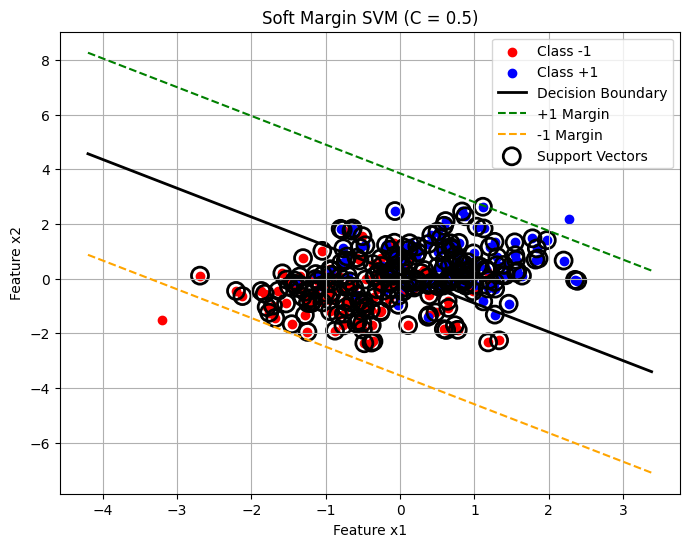

In [12]:
# 1.3 Q4
# Plotting for C=0.5
plot_svm(svm_c05, X_train,y_train, "Soft Margin SVM (C = 0.5)")


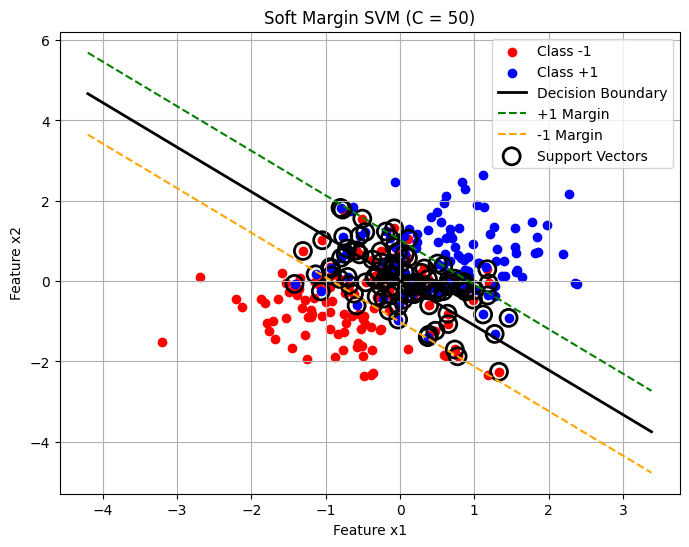

In [13]:
# 1.3 Q4
# Plotting for C=50
plot_svm(svm_c50, X_train, y_train, "Soft Margin SVM (C = 50)")

Section 1.3 Support Vector Machine

**Question5:**
Compare the two models: how does margin width change as C increases? How does the
number of support vectors change? Which model is more likely to be overfitting, and why?

**1.3 Q5**

**Answer5:**

### Comparison of the Two SVM Models

| Parameter | C = 0.5 | C = 50 | Notes |
|-----------|----------|---------|-------|
| Margin Width | 2.3145 | 1.2874 |       |
| Number of Support Vectors | 46 | 19 |       |
| Test Accuracy | 0.9167 | 0.9500 |       |

### Observations

1. **Margin Width**

  As the value of **C** increases from **0.5** to **50**, the margin width decreases. A larger value of **C** penalizes misclassified samples more heavily, causing the SVM to choose a narrower margin in order to correctly classify more training samples.

2. **Support Vectors**

  When **C** is small (0.5), the model allows a wider margin, so more training samples lie on or inside the margin and become support vectors. As **C** increases to **50**, the margin becomes narrower, and the number of support vectors generally decreases.

3. **Overfitting**

  The model trained with **C = 50** is more likely to overfit because it focuses on minimizing training errors by using a smaller margin. This makes the model more sensitive to individual training samples and may reduce its ability to generalize to unseen data.

The model with **C = 0.5** usually provides better generalization because it allows a wider margin and is less sensitive to noise in the training data.

**Section 2.1 K-Nearest Neighbours**


|          Class          | Label | Mean(x1,x2) | Samples |
|--------------------|------------:|----------------:|------:|
|          0         |     0      |      (-2,-2)      |  300  |
|          1         |     1      |      (2,2)      |  300  |

In [14]:
# 2.1 Q1
# Question 1: Generate the dataset above and split 70:30 into train/test.
# Answer 1:
# Generate Dataset


np.random.seed(42)

samples = 300

mean0 = [-2, -2]
mean1 = [2, 2]

covariance = np.eye(2)

# Class 0
X0 = np.random.multivariate_normal(mean0, covariance, samples)

y0 = np.zeros(samples, dtype=int)

# Class 1
X1 = np.random.multivariate_normal(mean1, covariance, samples)

y1 = np.ones(samples, dtype=int)

# Combine
X = np.vstack((X0, X1))
y = np.concatenate((y0, y1))

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 420
Testing Samples : 180


In [15]:
# 2.1  Q2
# Question 2: Implement K-Nearest Neighbours from scratch using Euclidean distance and majority vote.
# Answer 2:
import numpy as np

# KNN Classifier

class KNN:

    def __init__(self, k):

        self.k = k

    def fit(self, X, y):

        self.X_train = X
        self.y_train = y

    def predict(self, X):

        predictions = []

        for test_point in X:

            distances = np.sqrt(np.sum((self.X_train - test_point) ** 2, axis=1))

            nearest_indices = np.argsort(distances)[:self.k]

            nearest_labels = self.y_train[nearest_indices]

            prediction = np.bincount(nearest_labels).argmax()

            predictions.append(prediction)

        return np.array(predictions)

# Accuracy Function (moved outside the class and de-indented)
def accuracy(y_true, y_pred):
  return np.mean(y_true == y_pred)


In [16]:
# 2.1 Q3

# Question 3:Evaluate K ∈ {1,3,5,11,25}. Report training and test accuracy for each value of K
# Answer 3:
# Evaluate Different Values of K


k_values = [1, 3, 5, 11, 25]

train_accuracy = []
test_accuracy = []

for k in k_values:

    knn = KNN(k)

    knn.fit(X_train, y_train)

    train_prediction = knn.predict(X_train)
    test_prediction = knn.predict(X_test)

    train_acc = accuracy(y_train, train_prediction)
    test_acc = accuracy(y_test, test_prediction)

    train_accuracy.append(train_acc)
    test_accuracy.append(test_acc)

    print("=" * 40)
    print("K =", k)
    print("Training Accuracy :",train_acc.round(4))
    print(f"Testing Accuracy  : ",test_acc.round(4))

K = 1
Training Accuracy : 1.0
Testing Accuracy  :  0.9889
K = 3
Training Accuracy : 0.9976
Testing Accuracy  :  0.9889
K = 5
Training Accuracy : 0.9976
Testing Accuracy  :  0.9944
K = 11
Training Accuracy : 0.9976
Testing Accuracy  :  0.9889
K = 25
Training Accuracy : 0.9976
Testing Accuracy  :  0.9944


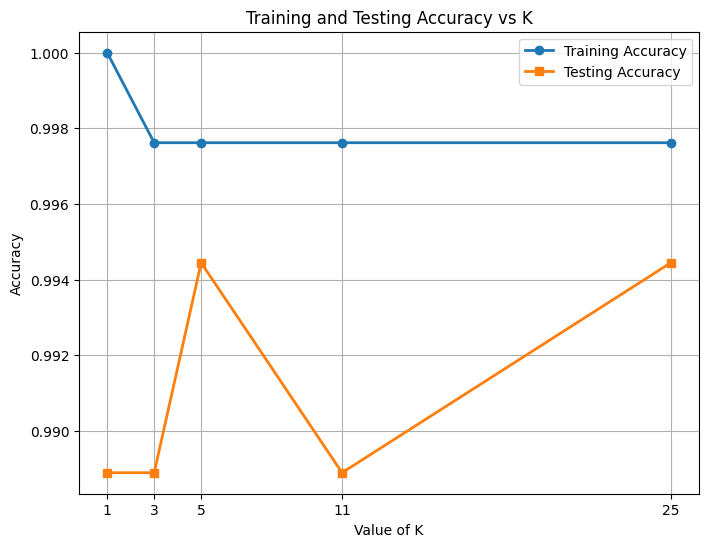

In [17]:
# 2.1 Q4

# Question 4: Plot accuracy vs. K, with both the training and test curves on the same axes.

# Answer 4:

# Plot Accuracy vs K


plt.figure(figsize=(8, 6))

plt.plot(k_values, train_accuracy, marker="o", linewidth=2, label="Training Accuracy")

plt.plot(k_values, test_accuracy, marker="s", linewidth=2, label="Testing Accuracy")

plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("Training and Testing Accuracy vs K")

plt.xticks(k_values)
plt.grid(True)
plt.legend()

plt.show()

**2.1 Q5**

**Question 5:** Identify the best K by test accuracy, and comment on which range of K looks like overfitting
and which looks like underfitting.

Answer 5:

**Best Value of K:**

The best value of K is 5, as it gives the highest testing accuracy.

**OverFitting:**

Smaller values of **K**, especially **K = 1**, tend to overfit the training data. The classifier becomes highly sensitive to individual training samples and noise, resulting in very high training accuracy but comparatively lower testing accuracy.

**Underfitting:**

Larger values of **K**, such as **K = 25**, tend to underfit the data. The classifier considers many neighbours while making predictions, producing smoother decision boundaries that may overlook important patterns in the data.

**Conclusion:**

The best value of **K** provides a good balance between bias and variance, resulting in the highest testing accuracy and better generalization to unseen data.

**2.2 Curse of Dimensionality**

| d (dimensions) | Class 0 mean | Class 1 mean | Samples/class |
|-----------|----------|---------|--------------|
| 2 | (-1,-1) | (1,1) |      300       |
| 20 | vector of -1's, length 20 | vector of +1's, length 20 |       300      |
| 100 | vector of -1's, length 100 | vector of +1's, length 100 |       300       |

In [18]:
# 2.2 Q1
# 2.2 Q2
# Question 1:For each value of d above, generate the two-class dataset and split 70:30
# Question 2:Train your KNN implementation with K = 5 (or the best K you found in Section 2.1, state
#            which you use) and report the test accuracy for every d.
# Questions 1 & 2

dimensions = [2, 20, 100]

# Use the best K obtained in Section 2.1
k = 5

test_accuracy = []

for d in dimensions:

    np.random.seed(42)

    # Mean vectors
    mean_class0 = -np.ones(d)
    mean_class1 = np.ones(d)

    # Identity covariance matrix
    covariance = np.eye(d)

    # Generate datasets
    X0 = np.random.multivariate_normal(mean_class0, covariance, 300)

    X1 = np.random.multivariate_normal(mean_class1, covariance, 300)

    y0 = np.zeros(300, dtype=int)
    y1 = np.ones(300, dtype=int)

    X = np.vstack((X0, X1))
    y = np.concatenate((y0, y1))

    # 70:30 Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)

    # Train KNN
    knn = KNN(k)
    knn.fit(X_train, y_train)

    # Test Accuracy
    predictions = knn.predict(X_test)

    accuracy = np.mean(predictions == y_test)

    test_accuracy.append(accuracy)

    print("=" * 40)
    print("Dimensions:", d)
    print("Test Accuracy:",accuracy.round(4))


Dimensions: 2
Test Accuracy: 0.9111
Dimensions: 20
Test Accuracy: 1.0
Dimensions: 100
Test Accuracy: 1.0


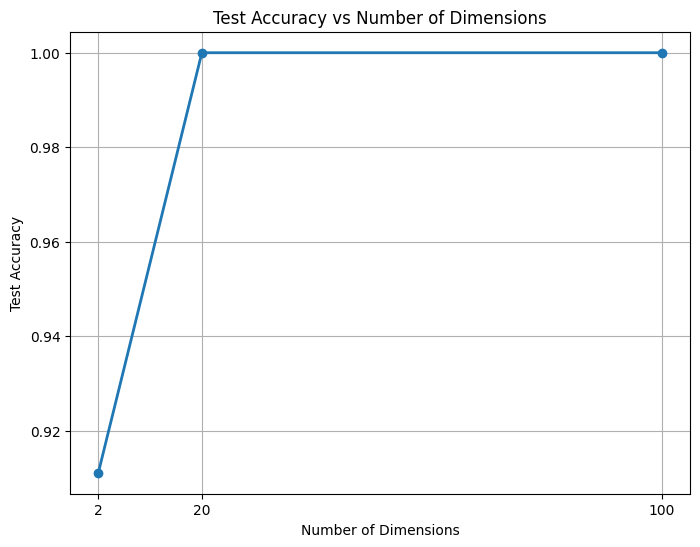

In [19]:
# 2.2 Q3
# Question 3:Plot test accuracy vs. d. In 3-4 sentences, explain the trend you observe, referring to what
#            happens to pairwise distances between points as dimensionality grows.
# Answer 3:
# Plot Test Accuracy vs Dimensions


plt.figure(figsize=(8,6))

plt.plot(
    dimensions,
    test_accuracy,
    marker='o',
    linewidth=2
)

plt.xlabel("Number of Dimensions")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Number of Dimensions")

plt.xticks(dimensions)

plt.grid(True)

plt.show()

**2.3 Naive Bayes (Pen-and-Paper)**

|  | Prior P(class) | P("free"=Yes class) | P("winner"=Yes class) |
|-----------|----------|---------|--------------|
| Spam | 0.40 | 0.70 |      0.60       |
| Not Spam | 0.60 | 0.05 |       0.02      |


## 2.3 Q1

Bayes' theorem is given by:

$$
P(\text{Class} \mid \text{free}, \text{winner})
=\frac{
P(\text{free}, \text{winner} \mid \text{Class})
P(\text{Class})
}
{
P(\text{free}, \text{winner})
}
$$

The Naive Bayes classifier assumes that the features are **conditionally independent** given the class.

Therefore,

$$
P(\text{free}, \text{winner} \mid \text{Class})
=P(\text{free} \mid \text{Class})
\times
P(\text{winner} \mid \text{Class})
$$

This simplifies Bayes' theorem to

$$
P(\text{Class} \mid \text{free}, \text{winner})
\propto
P(\text{Class})
\times
P(\text{free} \mid \text{Class})
\times
P(\text{winner} \mid \text{Class})
$$

**2.3 Q2**

Question 2: A new email contains the word “free” but not the word “winner.” Using the Naive Bayes
formula and the table above, compute the unnormalized posterior score for Spam and for
Not Spam, and state the predicted class. Show every step of the arithmetic.

### Spam

For the Spam class,
$$P(\text{Spam})=0.40$$
$$P(\text{free}=\text{Yes} \mid \text{Spam})=0.70$$

$$P(\text{winner}=\text{No} \mid \text{Spam})=1-0.60=0.40$$

The unnormalized posterior score is,
$$0.40\times0.70\times0.40=0.112$$

---

### Not Spam

$$P(\text{Not Spam})=0.60$$
$$P(\text{free}=\text{Yes} \mid \text{Not Spam})=0.05$$

$$P(\text{winner}=\text{No} \mid \text{Not Spam})=1-0.02=0.98$$

The unnormalized posterior score is,
$$0.60\times0.05\times0.98=0.0294$$

---

### Prediction

Since,
$$0.112 > 0.0294$$
the email is classified as **Spam**.

**2.3 Q3**

**Question 3:**
In 2–3 sentences, explain why this Naive Bayes classifier is generative, in contrast with the
Perceptron and SVM you built in Part 1, which are discriminative.

**Answer 3:**

Naive Bayes is a **generative** classifier because it models the probability distribution of each class and the probability of the observed features given that class. It uses Bayes' theorem to calculate the posterior probability and predict the most likely class.

In contrast, the Perceptron and Soft-Margin SVM are **discriminative** classifiers. They do not model the underlying probability distributions. Instead, they learn a decision boundary that directly separates the classes based on the training data.

# Section 2.4 – Putting It All Together

## 2.4 Q1
**Question 1**: Build one comparison table across every model built in this assignment (Perceptron, Soft Margin SVM, KNN, Naive Bayes) with columns: Model, Type (Discriminative/Generative), Test Accuracy (where applicable), One Strength, One Weakness.

| Model | Type | Test Accuracy | One Strength | One Weakness |
|--------|------|---------------|--------------|--------------|
| Perceptron | Discriminative | *0.9833* | Simple and fast for linearly separable data | Cannot handle non-linearly separable data well |
| Soft-Margin SVM | Discriminative | *C=0.5, Test Accuracy: 0.9167;   C=50,Test Accuracy: 0.9500* | Handles overlapping classes by maximizing the margin | Performance depends on the choice of C of the regularization paramteter C |
| K-Nearest Neighbours (KNN) | Discriminative | *0.9778* | Simple to implement and effective on small datasets | Performance decreases in high-dimensional data and prediction can be slow for large datasets |
| Naive Bayes | Generative | N/A (Pen-and-Paper) | Fast and computationally efficient | Assumes conditional independence between features, which may not hold in real world data |

## 2.4 Q2
Question 2:
**Write a short reflection (150–200 words) answering: (a) which model performed best overall,and why; (b) which model was most sensitive to a single hyperparameter choice (e.g. C or K); (c) which model’s performance was most affected by increasing dimensionality (refer toSection 2.2)**.

**Answer 2:**
Among all the models implemented in this assignment, the **Soft-Margin SVM** performed best overall because it was able to classify overlapping data effectively while maintaining a balance between classification accuracy and generalization. Unlike the Perceptron, which works well only for linearly separable data, the Soft-Margin SVM can tolerate some misclassified samples and still produce a robust decision boundary.

The **Soft-Margin SVM** was the most sensitive to the choice of its hyperparameter **C**. A smaller value of **C** produced a wider margin with better generalization, whereas a larger value of **C** reduced the margin and increased the possibility of overfitting. Similarly, the performance of KNN depended on the choice of **K**, but the effect of **C** on the SVM's decision boundary was more significant in this assignment.

The **K-Nearest Neighbours (KNN)** classifier was most affected by increasing dimensionality. As the number of dimensions increased, the distances between data points became more similar, making it difficult to identify meaningful nearest neighbours. This reduced the effectiveness of the distance-based classification and demonstrated the curse of dimensionality.